In [1]:
# импорт необходимых библиотек
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import rcParams
import math
import xgboost # conda install py-xgboost
import time
from tqdm import tqdm

In [2]:
fd_001_train = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt",sep=" ",header=None)

In [3]:
fd_001_test = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt",sep=" ",header=None)

In [4]:
fd_001_train.describe()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,0.0,0.0
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,NaN,NaN
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251,NaN,NaN
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,NaN,NaN
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,NaN,NaN
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,NaN,NaN
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,NaN,NaN
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,NaN,NaN


In [5]:
fd_001_train.drop(columns=[26,27],inplace=True)

In [6]:
fd_001_test.drop(columns=[26,27],inplace=True)

In [7]:
columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]

In [8]:
fd_001_train.columns = columns

In [9]:
fd_001_test.columns = columns

In [10]:
# первичное знакомство с данными
#initial acquaintance with data
fd_001_train.describe()

,unit_number,time_in_cycles,setting_1,setting_2,TRA,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [11]:
# удалим колонки с константными значениями, как не несущими информацию о состоянии агрегата
#delete columns with constant values ​​that do not carry information about the state of the unit
fd_001_train.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'],inplace=True)


## Отобразим взаимные корреляции признаков на "тепловой карте", для этого подготовим дополнительный признак "RUL", показывающий количество циклов до отказа в тренировочных данных

## We will display the mutual correlations of the signs on the "heat map", for this we will prepare an additional sign "RUL", showing the number of cycles to failure in the training data

In [12]:
# функция для подготовки тренировочных данных и формирования колонки RUL  с информациеей об оставшихся
#до поломки циклах
#function for preparing training data and forming a RUL column with information about the remaining
# before breaking cycles
def prepare_train_data(data, factor = 0):
    df = data.copy()
    fd_RUL = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    fd_RUL = pd.DataFrame(fd_RUL)
    fd_RUL.columns = ['unit_number','max']
    df = df.merge(fd_RUL, on=['unit_number'], how='left')
    df['RUL'] = df['max'] - df['time_in_cycles']
    df.drop(columns=['max'],inplace = True)
    
    return df[df['time_in_cycles'] > factor]


In [13]:
df = prepare_train_data(fd_001_train)

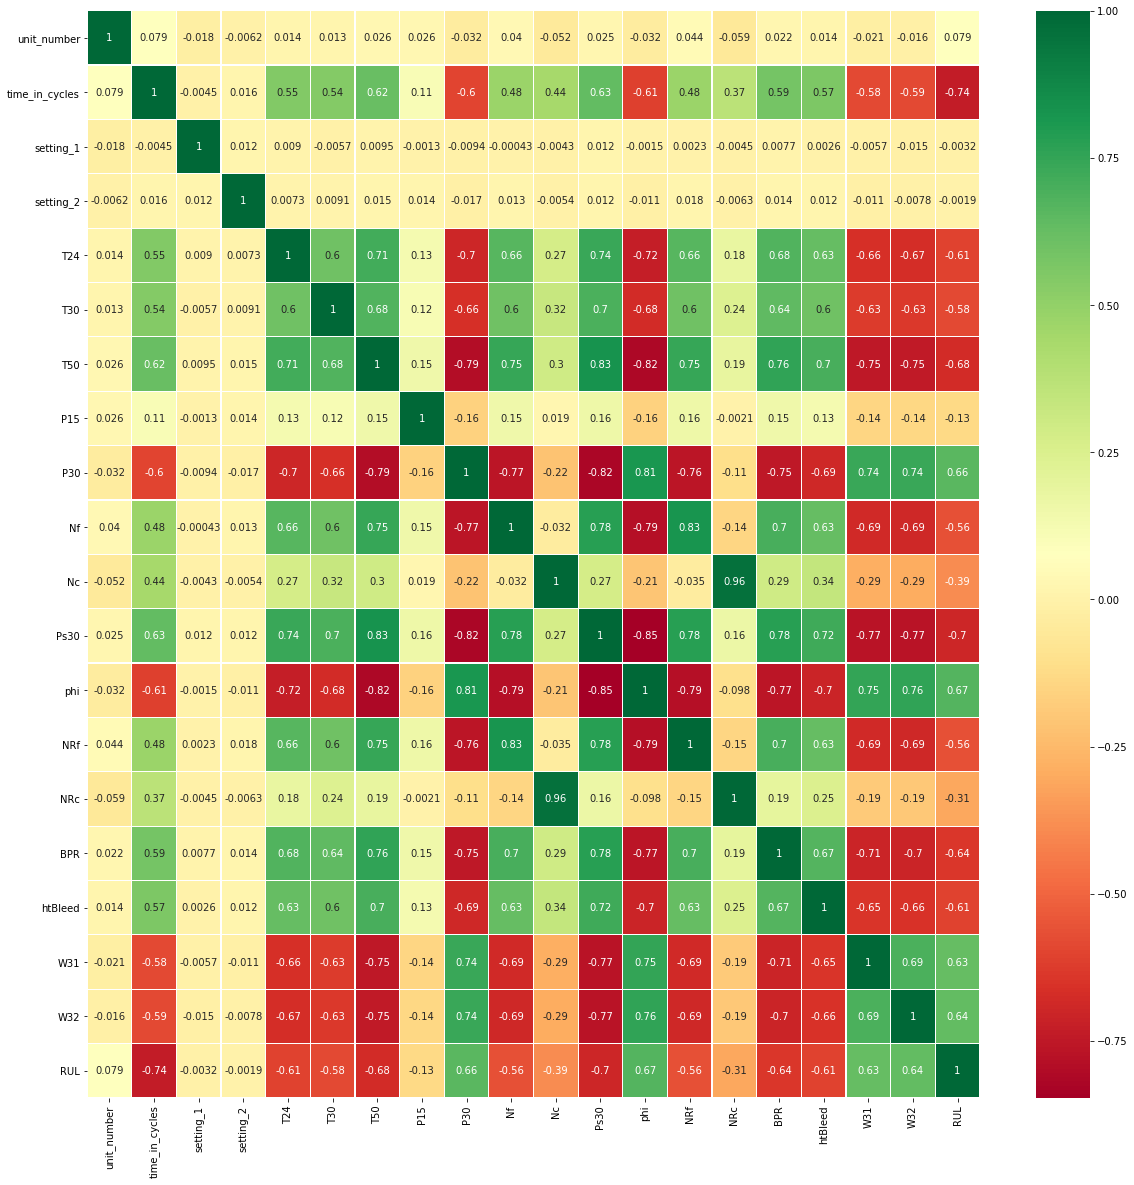

In [14]:
sns.heatmap(df.corr(),annot=True,cmap='RdYlGn',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(20,20)
plt.show()

## Функция ошибки для соревновательных данных

## Error Function for Competitive Data

In [15]:
# функция ошибки для соревновательных данных
#Error Function for Competitive Data
def score(y_true,y_pred,a1=10,a2=13):
    score = 0
    d = y_pred - y_true
    for i in d:
        if i >= 0 :
            score += math.exp(i/a2) - 1   
        else:
            score += math.exp(- i/a1) - 1
    return score
    
   

In [16]:
def score_func(y_true,y_pred):
    print(f' соревновательный счет {round(score(y_true,y_pred),2)}')
    print(f' mean absolute error {round(mean_absolute_error(y_true,y_pred),2)}')
    print(f' root mean squared error {round(mean_squared_error(y_true,y_pred),2) ** 0.5}')
    print(f' R2 score {round(r2_score(y_true,y_pred),2)}')
    return
    

## Удалим свойства, слабо коррелирующие с целевым показателем RUL: setting_1, setting_2, P15, unit_number, а также один из признаков, в сильно коррелирующих между собой (Nc и NRc имеют коэффициент корреляции 0.96, удалим NRc)


## We remove the properties that weakly correlate with the RUL target: setting_1, setting_2, P15, unit_number, as well as one of the features that are highly correlated with each other (Nc and NRc have a correlation coefficient of 0.96, remove NRc)

In [17]:
train_df = df.drop(columns = ['unit_number','setting_1','setting_2','P15','NRc'])

In [18]:
# функция для создания и тренировки моделей по алгоритмам "Random forest" и "XGBoost"
#function for creating and training models using the "Random forest" and "XGBoost" algorithms
def train_models(data,model = 'FOREST'):
    X = data.iloc[:,:14].to_numpy() 
    Y = data.iloc[:,14:].to_numpy()
    Y = np.ravel(Y)
    if model == 'FOREST':
         # параметры для моделей подобраны в подобном цикле, с введением в функцию дополнительного параметра param:
         #  parameters for models are selected in a similar cycle, with the introduction 
         # of an additional param parameter into the function:
         #for i in range(1,11):
         #     xgb = train_models(train_df,param=i,model="XGB",)
         #     y_xgb_i_pred = xgb.predict(X_001_test)
         #     print(f'param = {i}')
         #     score_func(y_true,y_xgb_i_pred)
        model = RandomForestRegressor(n_estimators=70, max_features=7, max_depth=5, n_jobs=-1, random_state=1)
        model.fit(X,Y)
        return model
    elif model == 'XGB':
        model = xgboost.XGBRegressor(n_estimators=110, learning_rate=0.018, gamma=0, subsample=0.8,
                           colsample_bytree=0.5, max_depth=3,silent=True)
        model.fit(X,Y)
        return model
    return
    

In [19]:
# функция для совместного отображения реальных и предсказанных значений
#function for joint display of real and predicted values

def plot_result(y_true,y_pred):
    rcParams['figure.figsize'] = 12,10
    plt.plot(y_pred)
    plt.plot(y_true)
    plt.tick_params(axis='x', which='both', bottom=False, top=False,labelbottom=False)
    plt.ylabel('RUL')
    plt.xlabel('training samples')
    plt.legend(('Predicted', 'True'), loc='upper right')
    plt.title('Сравнение реальных и предсказанных значений ')
    plt.show()
    return

## Подготовим тестовые данные для классификации
нужны только использовавшиеся при тренировке features и строка с максимальным для этого двигателя значением time_in_cycles (последняя)

Prepare test data for classification
only the features used in the training are needed and a line with the maximum value for this engine time_in_cycles (last)

In [20]:
fd_001_test.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'],inplace=True)

In [21]:
test_max = fd_001_test.groupby('unit_number')['time_in_cycles'].max().reset_index()
test_max.columns = ['unit_number','max']

In [22]:
fd_001_test = fd_001_test.merge(test_max, on=['unit_number'], how='left')

In [23]:
test = fd_001_test[fd_001_test['time_in_cycles'] == fd_001_test['max']].reset_index()

In [24]:
test.drop(columns=['index','max','unit_number','setting_1','setting_2','P15','NRc'],inplace = True)

In [25]:
X_001_test = test.to_numpy()

In [26]:
X_001_test.shape

(100, 14)

## Предсказание итогового результата для всех двигателей

Prediction of the final result for all engines

##  Обучим модель на тренировочных данных без удаленных свойств 'unit_number','setting_1','setting_2','P15','NRc'


Let's train the model on training data without the deleted properties 'unit_number', 'setting_1', 'setting_2', 'P15', 'NRc'

In [27]:
model_1 = train_models(train_df)

In [28]:
y_pred = model_1.predict(X_001_test)

In [29]:
RUL = pd.read_csv("/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt",sep=" ",header=None)

In [30]:
y_true = RUL[0].to_numpy()

## Соревновательный счет, средняя абсолютная ошибка, корень среднеквадратичной ошибки и коэффициент детерминации полученной модели:

Competitive score, the average absolute error, the root mean square error and the coefficient of determination of the resulting model:

In [31]:
score_func(y_true, y_pred)

 соревновательный счет 1057.2
 mean absolute error 19.25
 root mean squared error 24.45219826518671
 R2 score 0.65


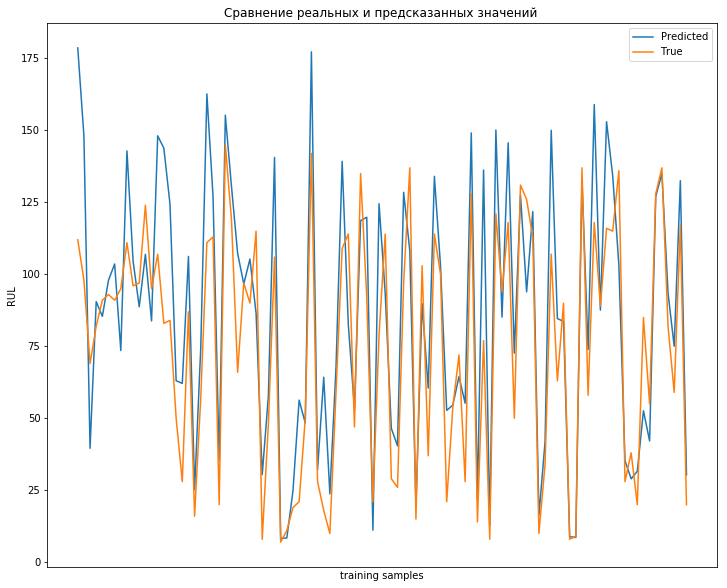

In [32]:
plot_result(y_true,y_pred)

## Попробуем улучшить алгоритм предсказания результатов, для этого будем обучать модель каждый раз заново для каждого отдельного предсказания, отбрасывая в тренировочном массиве значения по временной шкале (значения time_in_cycles) меньшие, чем последнее значение в массиве fd_001_test, то есть меньшие того значения для которого нужно предсказать RUL (remaining useful life)


Let’s try to improve the algorithm for predicting the results, for this we will train the model each time again for each individual prediction, discarding in the training array the values ​​on the timeline (time_in_cycles) are smaller than the last value in the fd_001_test array, that is, lower than the value for which RUL should be predicted (remaining useful life)

In [33]:
# для отбрасывания значений в тренировочном массиве используется параметр factor в 
# функции prepare_train_data, в test_data находятся подготовленные к распознаванию сэмплы, в первом столбце которых 
#  - значение времени в циклах, для которого производится предсказание RUL

# to discard values in the training array, use the factor parameter in
# prepare_train_data functions, in test_data are samples prepared for recognition, in the first column of which
# - value of time in cycles for which RUL is predicted
def single_train(test_data,train_data,algorithm):
    y_single_pred = []
    for sample in tqdm(test_data):
        time.sleep(0.01)
        single_train_df = prepare_train_data(train_data, factor = sample[0])
        single_train_df.drop(columns = ['unit_number','setting_1','setting_2','P15','NRc'],inplace = True)
        model = train_models(single_train_df,algorithm)
        y_p = model.predict(sample.reshape(1,-1))[0]
        y_single_pred.append(y_p)
    y_single_pred = np.array(y_single_pred)
    return y_single_pred

In [34]:
y_single_pred = single_train(X_001_test,fd_001_train,'FOREST')

100%|██████████| 100/100 [01:04<00:00,  1.55it/s]


## Отобразим полученные результаты

Display the results.

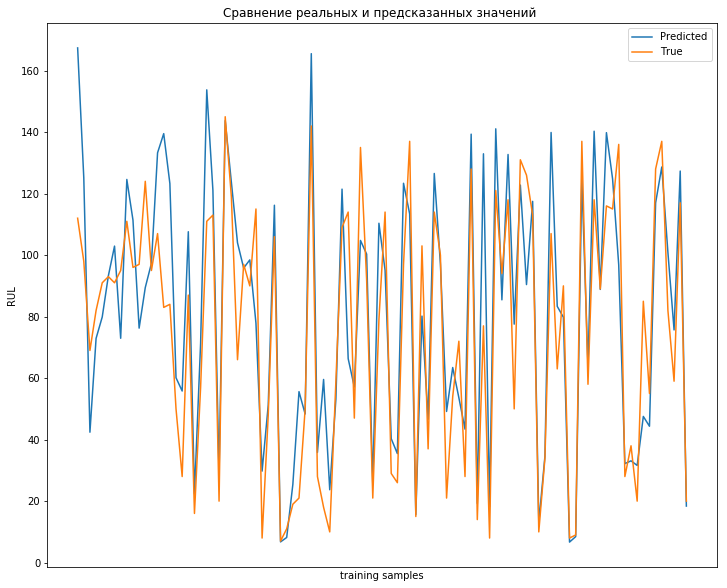

In [35]:
plot_result(y_true,y_single_pred)

## Соревновательный счет, средняя абсолютная ошибка и коэффициент детерминации улучшенной модели


## Competitive score, average absolute error and coefficient of determination of the improved model

In [36]:
score_func(y_true, y_single_pred)

 соревновательный счет 868.02
 mean absolute error 16.49
 root mean squared error 21.342445970413046
 R2 score 0.74


##   Модифицированным алгоритмом с индивидуальным обучением и предсказанием удалось существенно снизить MAE и повысить R2 score

Using a modified algorithm with individual training and prediction, it was possible to significantly reduce the MAE and increase the R2 score

## Так как данные датчиков сильно зашумлены, для улучшения предсказания попробуем следующий подход: предсказания будем делать на основе не одного (последнего) "среза" значений датчиков, как это делалось выше, а некоторого оптимизируемого (например по коэффициенту детерминации или средней абсолютной ошибки) количества предшествующих поломке значений. Для вывода итогового значения RUL воспользуемся средним значением всех предсказаний

Since the sensor data is very noisy, we will try the following approach to improve the prediction: we will make predictions based on not one (last) “slice” of the sensor values, as was done above, but some optimized (for example, by determination coefficient or mean absolute error) number of previous breaking values. To display the final value of RUL, we use the average value of all predictions

In [37]:
def prepare_test_data(fd_001_test,n=0):
    test = fd_001_test[fd_001_test['time_in_cycles'] == fd_001_test['max'] - n].reset_index()
    test.drop(columns=['index','max','unit_number','setting_1','setting_2','P15','NRc'],inplace = True)
    X_return = test.to_numpy()
    return X_return

In [38]:
N=5
y_n_pred = y_single_pred
for i in range(1,N):
    X_001_test = prepare_test_data(fd_001_test,i)
    y_single_i_pred = single_train(X_001_test,fd_001_train,'FOREST')    
    y_n_pred = np.vstack((y_n_pred,y_single_i_pred))  

100%|██████████| 100/100 [01:05<00:00,  1.52it/s]


## Посчитаем среднее значение предсказаний для каждого двигателя

We calculate the average value of predictions for each engine

In [39]:
y_multi_pred = np.mean(y_n_pred,axis = 0)

In [40]:
score_func(y_true,y_multi_pred)

 соревновательный счет 810.53
 mean absolute error 17.78
 root mean squared error 22.172505496673125
 R2 score 0.72


## Отобразим полученные результаты для среднего из 5 предсказаний

We display the results for the average of 5 predictions

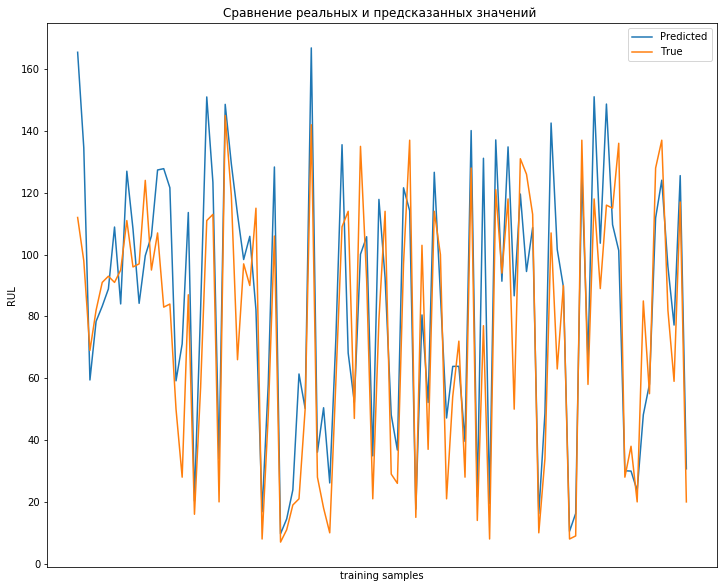

In [41]:
plot_result(y_true,y_multi_pred)

In [42]:
N=10
#Чтобы повторно не вычислять средний результат для 5 предсказаний, сохраненное значение y_multi_pred 
# заносится в y_n_pred, далее считаются предсказания для 5,6.... строки от последней для данного двигателя

# In order not to recalculate the average result for 5 predictions, the stored value y_multi_pred
# is entered in y_n_pred, then the predictions for 5,6,7 .... lines from the last for the given engine
y_n_pred = y_multi_pred
for i in range(5,N):
    X_001_test = prepare_test_data(fd_001_test,i)
    y_single_i_pred = single_train(X_001_test,fd_001_train,'FOREST')    
    y_n_pred = np.vstack((y_n_pred,y_single_i_pred))  

100%|██████████| 100/100 [01:08<00:00,  1.46it/s]


In [43]:
y_multi_pred_10 = np.mean(y_n_pred,axis = 0)

In [44]:
score_func(y_true,y_multi_pred_10)

 соревновательный счет 990.42
 mean absolute error 20.55
 root mean squared error 24.55605831561735
 R2 score 0.65


## Отобразим полученные результаты для среднего из 10 предсказаний


We display the results for an average of 10 predictions

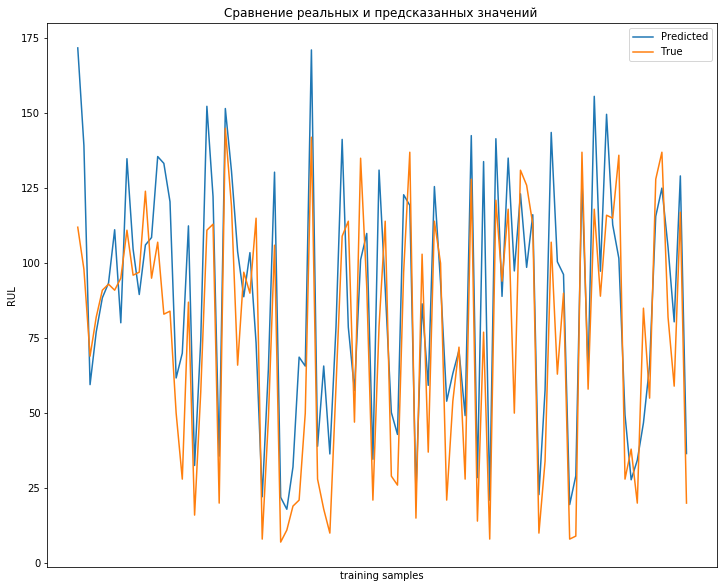

In [45]:
plot_result(y_true,y_multi_pred_10)

## Очевидно, что с дальнейшим ростом числа предсказаний для вывода среднего качество ответов модели не улучшается, в дальнейшем в работе будем использовать y_multi_pred (среднее из 5 индивидуальных предсказаний)

Obviously, with a further increase in the number of predictions for deriving the average, the quality of the model’s answers does not improve, in the future we will use y_multi_pred (the average of 5 individual predictions)

## Сравним полученные результаты с еще одной моделью - XGBoost

Compare the results with another model - XGBoost

In [46]:
xgb = train_models(train_df,model="XGB")

In [47]:
y_xgb_pred = xgb.predict(X_001_test)

In [48]:
score_func(y_true,y_xgb_pred)

 соревновательный счет 1140.49
 mean absolute error 20.39
 root mean squared error 24.557483584439186
 R2 score 0.65


## По метрикам оценки алгоритмов регрессии результат хуже, чем для "случайного леса"
Метрики для RandomForestRegressor

соревновательный счет 1057.2

 mean absolute error 19.25
 
 root mean squared error 24.45219826518671
 
 R2 score 0.65

According to regression algorithm estimation metrics, the result is worse than for a "random forest"
Metrics for RandomForestRegressor

Competitive Score 1057.2

 mean absolute error 19.25
 
 root mean squared error 24.45219826518671
 
 R2 score 0.65

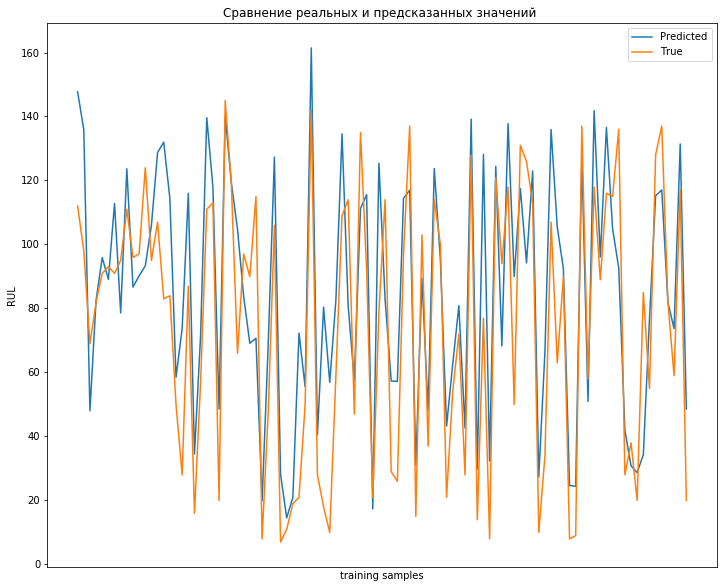

In [49]:
plot_result(y_true,y_xgb_pred)

## Индивидуальные предсказания для XGBoost:

Individual predictions for XGBoost:

In [50]:
y_single_xgb_pred = single_train(X_001_test,fd_001_train,'XGB')

100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


In [51]:
score_func(y_true,y_single_xgb_pred)

 соревновательный счет 1139.26
 mean absolute error 18.9
 root mean squared error 22.63294059551255
 R2 score 0.7


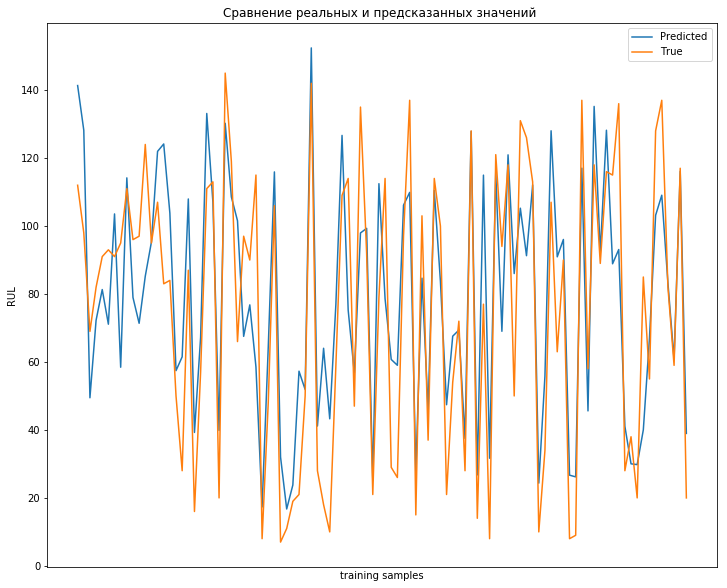

In [52]:
plot_result(y_true,y_single_xgb_pred)

In [53]:
N=5
y_n_pred = y_single_xgb_pred
for i in range(1,N):
    X_001_test = prepare_test_data(fd_001_test,i)
    y_single_i_pred = single_train(X_001_test,fd_001_train,'XGB')    
    y_n_pred = np.vstack((y_n_pred,y_single_i_pred)) 

100%|██████████| 100/100 [01:04<00:00,  1.55it/s]


In [54]:
y_5_pred_xgb = np.mean(y_n_pred,axis = 0)

In [55]:
score_func(y_true,y_5_pred_xgb)

 соревновательный счет 1136.65
 mean absolute error 16.14
 root mean squared error 20.620135790047552
 R2 score 0.75


## Аналогично, все метрики, кроме соревновательной функции ошибки (по сравнению с совместным предсказанием)  улучшили свое значение

Similarly, all metrics, except for the competitive error function (compared to the joint prediction) have improved their value

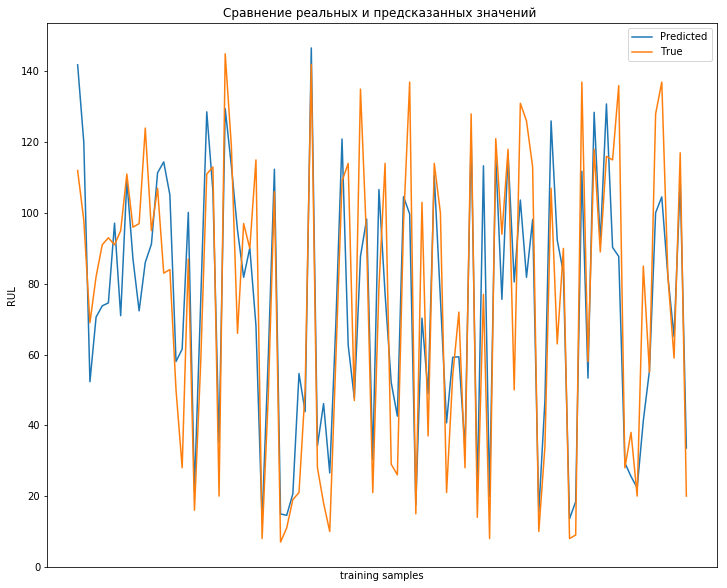

In [56]:
plot_result(y_true,y_5_pred_xgb)

In [57]:
compare = pd.DataFrame(list(zip(y_true, y_pred, y_single_pred,y_multi_pred,y_multi_pred_10,y_xgb_pred,y_single_xgb_pred)), 
               columns =['True','Forest_Predicted','Forest_Single_predicted','multi_5','multi_10'
                         ,'XGBoost','XGBoost_single']) 
compare['unit_number'] = compare.index + 1

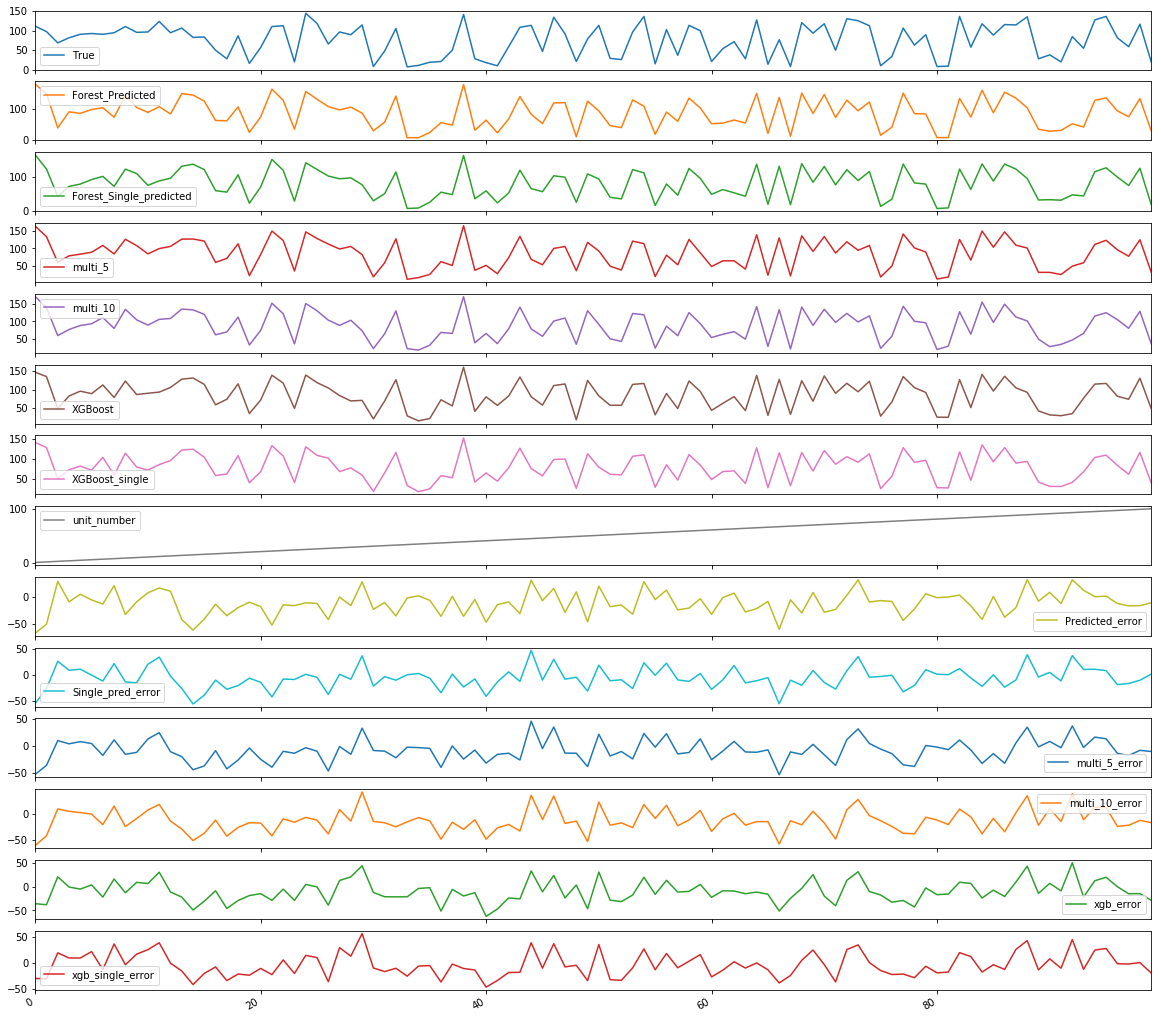

In [58]:
compare['Predicted_error'] = compare['True'] - compare['Forest_Predicted']
compare['Single_pred_error'] = compare['True'] - compare['Forest_Single_predicted']
compare['multi_5_error'] = compare['True'] - compare['multi_5']
compare['multi_10_error'] = compare['True'] - compare['multi_10']
compare['xgb_error'] = compare['True'] - compare['XGBoost']
compare['xgb_single_error'] = compare['True'] - compare['XGBoost_single']
ax1 = compare.plot(subplots=True, sharex=True, figsize=(20,20))

## Ошибки во всех алгоритмах сильно коррелируют, для дальнейшего улучшения прогнозов алгоритма, вероятно нужна предобработка тренировочных и,  возможно тестовых данных для исключения выбросов

Errors in all algorithms are strongly correlated, to further improve the forecasts of the algorithm, pre-processing of training and possibly test data is necessary to eliminate outliers

## Для получения практической ценности от данных используем алгоритмы бинарной классификации для планирования технического обслуживания ,посчитаем какую прибыль (или убыток) может принести анализ и планирование ТО для гипотетической авиакомпании
https://github.com/Samimust/predictive-maintenance/blob/master/Model%20Selection%20-%20Binary%20Classifiaction.ipynb

To obtain practical value from the data, we use binary classification algorithms for maintenance planning, calculate what profit (or loss) analysis and maintenance planning can bring for a hypothetical airline

https://github.com/Samimust/predictive-maintenance/blob/master/Model%20Selection%20-%20Binary%20Classifiaction.ipynb

## Создадим классификатор, который будет отвечать на вопрос: "Текущий ресурс двигателя больше или меньше 10 циклов" ? Предполагается, что это достаточное время для подготовки и начала технического обслуживания.


Let's create a classifier that will answer the question: "Current engine resource more or less than 10 cycles"? It is assumed that this is sufficient time to prepare and start maintenance.

## Expected Value Calculation:
Based on the book: Data Science for Business, https://www.amazon.com/Data-Science-Business-Data-Analytic-Thinking/dp/1449361323 . Expected Value is a method to compare different classification models by constructing cost-benefit matrix in line with the confusion matrix, and then convert model performance to a single monetary value by multiplying confusion matrix into the cost-benefit matrix.

Cost-benefit matrix should be designed by domain expert. Let us assume the following:

True Positive (TP) has benefit of USD 300K: engines that need maintenance and correctly selected by the model.

True Negative (TN) has benefit of USD 0K: engines that are OK and not selected by the model.

False Positive (FP) has cost of USD -100K: engines that are OK but selected by the model.

False Negative (FN) has cost of USD -200K: engines that need maintenance but not selected by the model.

In [59]:
# формирование целевой переменной label, TTF - время до поломки
TTF = 10
train_df['label'] = np.where(train_df['RUL'] <= TTF, 1, 0 )

formation of the target variable label, TTF - time to failure

In [60]:
train_df.head()

,time_in_cycles,T24,T30,T50,P30,Nf,Nc,Ps30,phi,NRf,BPR,htBleed,W31,W32,RUL,label
0,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8.4195,392,39.06,23.4190,191,0
1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392,39.00,23.4236,190,0
2,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390,38.95,23.3442,189,0
3,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392,38.88,23.3739,188,0
4,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393,38.90,23.4044,187,0


## Отобразим диаграмму рассеивания двух параметров с разделением по целевому признаку


We display the scattering diagram of two parameters with a separation according to the target attribute

Text(0.5, 1.0, 'Диаграмма рассеивания T50 от Nc')

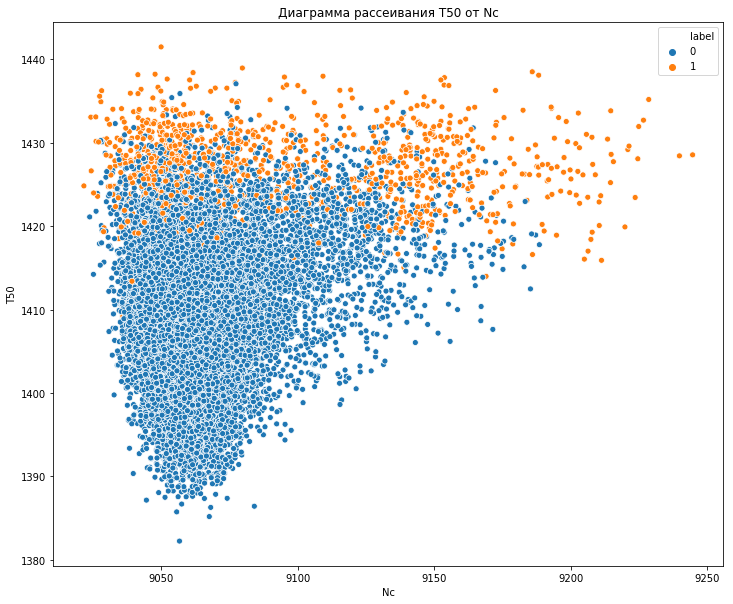

In [61]:
sns.scatterplot(x="Nc", y="T50", hue="label", data=train_df)
plt.title('Диаграмма рассеивания T50 от Nc')

## Подготовим данные для классификации

In [62]:
#исключаем свойство RUL и формируем массив признаков и целевой переменной
# exclude the RUL property and form an array of attributes and the target variable
X_class = train_df.iloc[:,:14].to_numpy() 
Y_class = train_df.iloc[:,15:].to_numpy()
Y_class = np.ravel(Y_class)

In [63]:
# Балансировка классов для улучшения работы классификатора

# Class balancing to improve classifier performance
from imblearn.over_sampling import RandomOverSampler
#from imblearn.under_sampling import RandomUnderSampler
ros = RandomOverSampler(random_state=0)
ros.fit(X_class, Y_class)
X_resampled, y_resampled = ros.fit_sample(X_class, Y_class)
print('Количество элементов до операции:', len(X_class))
print('Количество элементов после операции:', len(X_resampled))

Using TensorFlow backend.


Количество элементов до операции: 20631
Количество элементов после операции: 39062


In [64]:
# Здесь делим данные на обучающую выборку и тестовую , test_size = 0.2 задает долю тестовой выборки = 20%

#
# Here we divide the data into the training sample and the test one, 
#test_size = 0.2 sets the proportion of the test sample = 20%
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,test_size = 0.2,random_state = 3)

In [65]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [66]:
forest = RandomForestClassifier(n_estimators=70 ,max_depth = 8, random_state=193)
forest.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=8, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=70,
                       n_jobs=None, oob_score=False, random_state=193,
                       verbose=0, warm_start=False)

In [67]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0,
              learning_rate=0.1, max_delta_step=0, max_depth=3,
              min_child_weight=1, missing=None, n_estimators=100, n_jobs=1,
              nthread=None, objective='binary:logistic', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
              silent=None, subsample=1, verbosity=1)

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [69]:
def classificator_score(y_,y_p):
    print(f' accuracy score {round(accuracy_score(y_, y_p),2)}')
    print(f' precision score {round(precision_score(y_, y_p),2)}')
    print(f' recall score {round(recall_score(y_, y_p),2)}')
    print(f' F1 score {round(f1_score(y_, y_p),2)}')
    return

## Метрики для RandomForestClassifier

Metrics for RandomForestClassifier

In [70]:
classificator_score(y_test,forest.predict(X_test))

 accuracy score 0.98
 precision score 0.96
 recall score 1.0
 F1 score 0.98


## Метрики для XGBClassifier

In [71]:
y_xgb_pred = model_xgb.predict(X_001_test)
classificator_score(y_test,model_xgb.predict(X_test))

 accuracy score 0.98
 precision score 0.97
 recall score 1.0
 F1 score 0.98


In [72]:
test.head()

,time_in_cycles,T24,T30,T50,P30,Nf,Nc,Ps30,phi,NRf,BPR,htBleed,W31,W32
0,31,642.58,1581.22,1398.91,554.42,2388.08,9056.40,47.23,521.79,2388.06,8.4024,393,38.81,23.3552
1,49,642.55,1586.59,1410.83,553.52,2388.10,9044.77,47.67,521.74,2388.09,8.4505,391,38.81,23.2618
2,126,642.88,1589.75,1418.89,552.59,2388.16,9049.26,47.88,520.83,2388.14,8.4119,395,38.93,23.2740
3,106,642.78,1594.53,1406.88,552.64,2388.13,9051.30,47.65,521.88,2388.11,8.4634,395,38.58,23.2581
4,98,642.27,1589.94,1419.36,553.29,2388.10,9053.99,47.46,521.00,2388.15,8.4362,394,38.75,23.4117


In [73]:
X_001_test = test.to_numpy()

## сформируем обобщенную таблицу для предсказанных и верных значений

we will form a generalized table for predicted and correct values

In [74]:
# предсказание для X_001_test, время до поломки = TTF =10
predicted = pd.DataFrame()
predicted ['forest'] =  forest.predict(X_001_test)
predicted['XGB'] = y_xgb_pred
predicted['RUL']=RUL[0]
predicted['true_label'] = np.where(y_true <= TTF, 1, 0 )
predicted['unit_number'] = predicted.index + 1

In [75]:
predicted.head()

,forest,XGB,RUL,true_label,unit_number
0,0,0,112,0,1
1,0,0,98,0,2
2,0,0,69,0,3
3,0,0,82,0,4
4,0,0,91,0,5


In [76]:
# истинные значения TTF <= 10
predicted[predicted['true_label'] == 1]

,forest,XGB,RUL,true_label,unit_number
30,1,1,8,1,31
33,1,1,7,1,34
41,1,1,10,1,42
67,1,0,8,1,68
75,1,1,10,1,76
80,1,1,8,1,81
81,1,0,9,1,82


In [77]:
# двигатели, для которых алгоритм классификации RandomForest дал неверные предсказания
# engines for which the RandomForest classification algorithm gave incorrect predictions
predicted[predicted['true_label'] != predicted['forest']]

,forest,XGB,RUL,true_label,unit_number
34,1,1,11,0,35
35,1,0,19,0,36
48,1,0,21,0,49
55,1,1,15,0,56


In [78]:
# двигатели, для которых алгоритм классификации XGBoost дал неверные предсказания
# engines for which the XGBoost classification algorithm gave incorrect predictions
predicted[predicted['true_label'] != predicted['XGB']]

,forest,XGB,RUL,true_label,unit_number
19,0,1,16,0,20
34,1,1,11,0,35
55,1,1,15,0,56
67,1,0,8,1,68
81,1,0,9,1,82


In [79]:
y_true_class = np.where(y_true <= TTF, 1, 0 )
y_pred_class = predicted['forest'].tolist()

Функция для вычисления ожидаемой прибыли, как описано выше

Function for calculating expected profits as described above

In [80]:
def expected_profit(y_true,y_pred):
    TP=0
    FP=0
    TN=0
    FN=0
    for i in range(len(y_true)):
        if (y_true[i] != y_pred[i]) & (y_pred[i] == 1):
            FP += 1
        elif (y_true[i] != y_pred[i]) & (y_pred[i] == 0):
            FN += 1
        elif (y_true[i] == y_pred[i]) & (y_pred[i] == 0):
            TN += 1
        else:
            TP += 1
    print(f'TP ={TP}, TN = {TN}, FP = {FP}, FN = {FN}')
    print (f'ожидаемая прибыль {(300 * TP - 200 * FN - 100 * FP) * 1000}')
    return 
        

In [81]:
expected_profit(y_true_class,y_pred_class)

TP =7, TN = 89, FP = 4, FN = 0
ожидаемая прибыль 1700000


In [82]:
expected_profit(y_true_class,y_xgb_pred)

TP =5, TN = 90, FP = 3, FN = 2
ожидаемая прибыль 800000


## Ожидаемая прибыль для Random Forest оказалась выше


## Вывод: предложенные алгоритмы классификации показывают полезные результаты на тестовых данных и могут использоваться для получения экономии средств при проведении предупредительного ремонта авиадвигателей, для оценки примерного оставшегося ресурса двигателя (если в конкретных условиях допустима соответствующая погрешность) возможно его применение совместно с описанными выше алгоритмами регрессии

The expected profit for Random Forest is higher.

## Conclusion: the proposed classification algorithms show useful results on test data and can be used to obtain cost savings during preventive maintenance of aircraft engines, to estimate the approximate remaining engine life (if the corresponding error is permissible under specific conditions) it can be used in conjunction with the regression algorithms described above